In [1]:
import os
import glob

import anndata
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.font_manager as fm
import numpy as np
import pandas as pd
import scanpy as sc
import scvi
import scipy.sparse as sp
import seaborn as sns
import torch

/home/dmullane/micromamba/envs/scvi-env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
colors = [
    '#FF1B5E',  # coral
    '#FFDB57',  # yellow
    '#438CFD',  # blue
    '#FF8C00',  # orange
    '#80F15E',  # lime green
    '#03FFFF',  # cyan
    '#5941A9',  # purple
    '#E980FC',  # magenta
    '#1A1A2E',  # navy
    '#F5F0FF',  # lavender white
    '#C17F3E',  # amber brown
]
extended_colors = [
    '#2E2A3A',
    '#FF8DAF', '#FF1B5E',
    '#FFEDA0', '#FFDB57',
    '#A4C8FE', '#438CFD',
    '#FFCF80', '#FF8C00',
    '#C4F9AE', '#80F15E',
    '#A0FFFF', '#03FFFF',
    '#A99FD4', '#5941A9',
    '#F4BFFE', '#E980FC',
    '#E8E4F0', '#C4BDD6',
    '#E8C89A', '#C17F3E'
]

In [3]:
worms = pd.read_csv('../results/worm6_final/DNA_analysis/obs.csv', index_col=0)['donor'].sort_values().unique().tolist()
pal = {worm: extended_colors[i] for i, worm in enumerate(worms)}

In [4]:
fm._load_fontmanager(try_read_cache=False)
for f in glob.glob(os.path.expanduser('~/.local/share/fonts/texgyreheros*.otf')):
    fm.fontManager.addfont(f)

mpl.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['TeX Gyre Heros'],
    'font.size': 12,
    'axes.linewidth': 2.5,
    'xtick.major.width': 2.5,
    'ytick.major.width': 2.5,
    'xtick.minor.width': 2.0,
    'ytick.minor.width': 2.0,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
})

In [5]:
scvi.settings.seed = 0
print('Last run with scvi-tools version:', scvi.__version__)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'using: {device}')

[rank: 0] Seed set to 0


Last run with scvi-tools version: 1.4.1
using: cuda


# Load

In [6]:
adata = sc.read_h5ad('../CapGTA_dev/results/worm6_final/manual_annotation_arms/B_current/adata_annotated.h5ad')
adata.var_names = adata.var['wormbase_id'].astype(str).values
adata = adata[:, ~adata.var_names.duplicated()].copy()
adata

AnnData object with n_obs × n_vars = 2404 × 46748
    obs: 'total_counts', 'genes_detected', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'soupx_rho', 'soupx_nUMIs_pre', 'soupx_nUMIs_post', 'soupx_cluster', 'score_pan_neuronal', 'score_body_wall_muscle', 'score_intestine', 'score_seam_cell', 'score_spermatocyte_spermatid', 'score_germline_progenitor_meiotic', 'score_coelomocyte', 'score_head_mesodermal_cell_hmc', 'score_gonadal_sheath', 'score_distal_tip_cell', 'score_spermatheca', 'score_uterine_cell', 'score_vulval_muscle', 'score_pharyngeal_muscle', 'score_pharyngeal_gland_cell', 'score_pharyngeal_marginal_cell', 'score_excretory_cell', 'score_excretory_gland_cell', 'score_rectal_gland', 'score_anal_muscle', 'score_XXX_cell', 'score_glia_all', 'score_glia_sheath_AMsh_PHsh', 'score_glia_socket_AMso_PHso', 'score_CEPsh_glia', 'score_lit_in

In [7]:
joint = sc.read_h5ad('../results/worm6_final/DNA_analysis/joint_variants_process.h5ad', backed='r')
adata.obs['donor'] = joint.obs['donor'].reindex(adata.obs_names).values
adata = adata[~adata.obs['donor'].astype(str).isin(['worm02', 'worm04', 'worm14', 'worm19', 'background'])].copy()
adata.obs['donor'].value_counts()

donor
worm07    186
worm12    152
worm20    146
worm01    141
worm10    132
worm05    123
worm16    121
worm09    114
worm18    106
worm06    103
worm15     90
worm11     87
worm03     81
worm17     71
worm08     70
worm13     52
Name: count, dtype: int64

In [8]:
ref = sc.read_h5ad('../CapGTA_dev/next_iteration/T1_1_reference_degradation/T1_1b_stage1_5_neuron_downsampled/degraded_seeds/taylor2020_degraded_seed0.h5ad')
ref.layers['counts'] = ref.X.copy()
ref

AnnData object with n_obs × n_vars = 31937 × 22469
    obs: 'study', 'sample_batch', 'sample', 'sample_description', 'barcode', 'cell_type', 'cell_subtype', 'anchor_tissue'
    var: 'gene_id', 'gene_name', 'p_g_pooled'
    uns: 'degradation_config'
    layers: 'counts'

# Coembedding

In [9]:
sc.pp.filter_genes(ref, min_cells=3)
sc.pp.highly_variable_genes(ref, flavor='seurat_v3', n_top_genes=2000, layer='counts')
hvg = ref.var_names[ref.var['highly_variable']]
len(hvg)

2000

In [10]:
query = adata.copy()
query.obs['cell_type'] = 'Unannotated'

common = ref.var_names.intersection(query.var_names).intersection(hvg)
ref_sub = ref[:, common].copy()
query_sub = query[:, common].copy()
len(common)

1981

In [11]:
adata_concat = anndata.concat(
    [ref_sub, query_sub],
    label='assay',
    keys=['cengen_taylor2020', 'capgta'],
    merge='unique',
)
adata_concat.layers['counts'] = sp.vstack([
    ref_sub.layers['counts'].tocsr() if sp.issparse(ref_sub.layers['counts']) else sp.csr_matrix(ref_sub.layers['counts']),
    query_sub.layers['counts'].tocsr() if sp.issparse(query_sub.layers['counts']) else sp.csr_matrix(query_sub.layers['counts']),
]).tocsr()
adata_concat.X = adata_concat.layers['counts'].copy()
print(adata_concat.obs['assay'].value_counts())
adata_concat

assay
cengen_taylor2020    31937
capgta                1775
Name: count, dtype: int64


AnnData object with n_obs × n_vars = 33712 × 1981
    obs: 'cell_type', 'assay'
    var: 'gene_id', 'gene_name', 'p_g_pooled', 'n_cells', 'highly_variable_rank', 'variances', 'variances_norm', 'wormbase_id', 'n_junctions', 'exonic_length', 'detectability_k', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'dispersions', 'dispersions_norm', 'is_cuticle_molt_oscillator', 'is_heat_shock', 'is_mitochondrial', 'is_msp_family', 'is_ribosomal_rRNA', 'is_ubiquitous_high_expressor', 'is_unstable_reference_gene_Ghaddar2023', 'is_vitellogenin'
    varm: 'PCs'
    layers: 'counts'

### `scVI`

In [12]:
scvi.model.SCVI.setup_anndata(adata_concat, layer='counts', batch_key='assay')

In [13]:
scvi_model = scvi.model.SCVI(adata_concat, n_latent=30, n_layers=2, dispersion='gene-batch')

In [14]:
scvi_model.train(max_epochs=400, early_stopping=True)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
SLURM auto-requeueing enabled. Setting signal handlers.
/home/dmullane/micromamba/envs/scvi-env/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.
/home/dmullane/micromamba/envs/scvi-env/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argumen

Epoch 400/400: 100%|██████████| 400/400 [22:01<00:00,  3.39s/it, v_num=1, train_loss=153]

`Trainer.fit` stopped: `max_epochs=400` reached.


Epoch 400/400: 100%|██████████| 400/400 [22:01<00:00,  3.30s/it, v_num=1, train_loss=153]


In [15]:
SCVI_LATENT_KEY = 'X_scVI'
adata_concat.obsm[SCVI_LATENT_KEY] = scvi_model.get_latent_representation()
sc.pp.neighbors(adata_concat, use_rep=SCVI_LATENT_KEY)
sc.tl.umap(adata_concat, min_dist=0.3)

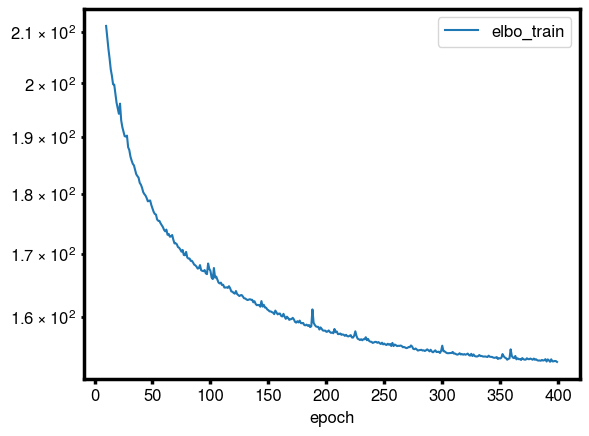

In [16]:
scvi_model.history['elbo_train'].iloc[10:].plot(logy=True)
plt.show()

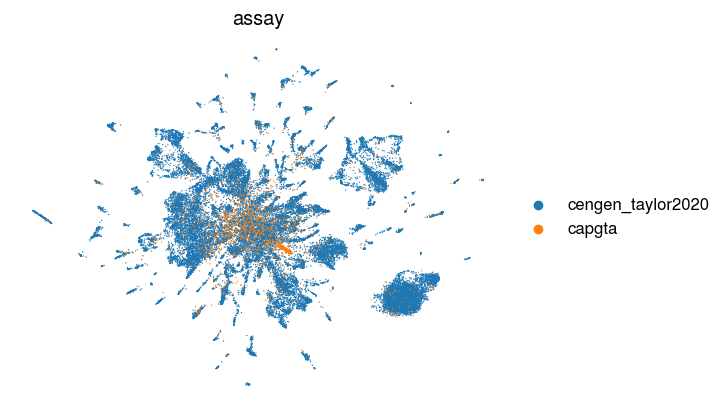

In [17]:
sc.pl.umap(adata_concat, color=['assay'], frameon=False, ncols=1)

### `scANVI`

In [18]:
SCANVI_CELLTYPE_KEY = 'celltype_scanvi'
adata_concat.obs[SCANVI_CELLTYPE_KEY] = 'Unknown'
ref_mask = adata_concat.obs['assay'] == 'cengen_taylor2020'
adata_concat.obs.loc[ref_mask, SCANVI_CELLTYPE_KEY] = adata_concat.obs.loc[ref_mask, 'cell_type'].astype(str).values

In [19]:
scanvi_model = scvi.model.SCANVI.from_scvi_model(
    scvi_model,
    adata=adata_concat,
    unlabeled_category='Unknown',
    labels_key=SCANVI_CELLTYPE_KEY,
)

/home/dmullane/micromamba/envs/scvi-env/lib/python3.11/site-packages/scvi/data/fields/_dataframe_field.py:187: UserWarning: Category 107 in adata.obs['_scvi_labels'] has fewer than 3 cells. Models may not train properly.
  categorical_mapping = _make_column_categorical(
/home/dmullane/micromamba/envs/scvi-env/lib/python3.11/site-packages/scvi/data/fields/_scanvi.py:56: UserWarning: Category 107 in adata.obs['_scvi_labels'] has fewer than 3 cells. Models may not train properly.
  mapping = _make_column_categorical(


In [ ]:
scanvi_model.train(max_epochs=400, early_stopping=True)

INFO     Training for 400 epochs.                                                                                  


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
SLURM auto-requeueing enabled. Setting signal handlers.
/home/dmullane/micromamba/envs/scvi-env/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.
/home/dmullane/micromamba/envs/scvi-env/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argumen

Epoch 2/400:   0%|          | 1/400 [00:11<1:16:33, 11.51s/it, v_num=1, train_loss=229]

In [ ]:
SCANVI_LATENT_KEY = 'X_scANVI'
SCANVI_PREDICTION_KEY = 'C_scANVI'
adata_concat.obsm[SCANVI_LATENT_KEY] = scanvi_model.get_latent_representation()
adata_concat.obs[SCANVI_PREDICTION_KEY] = scanvi_model.predict()

In [ ]:
sc.pp.neighbors(adata_concat, use_rep=SCANVI_LATENT_KEY)
sc.tl.umap(adata_concat, min_dist=0.3)
for r in [0.3, 0.6, 1.0, 1.5]:
    sc.tl.leiden(adata_concat, resolution=r, key_added=f'leiden_{r}')

In [ ]:
sc.pl.umap(adata_concat, color=['assay', SCANVI_PREDICTION_KEY], frameon=False, ncols=1)

# Save

In [ ]:
adata_concat.write_h5ad('../CapGTA_dev/results/worm6_final/adata_gex_scanvi_asymmetric.h5ad')